# ML Midterm Project Report #

Justyen Nguyen

ITAI-1371


## 1. Introduction & Literature Review ##

The problem I want to model exists where companies would want to give users recommendations on something to watch or buy. In order to do that, they would have to know what your current interests are based on your current browsing. Also, they would have to be able to rank those recommendations for your interests so you don't just brush it off as an annoying ad. Ultimately, the recommendations and ranking depend on context.

In Umamusume: Pretty Derby (Uma), sometimes content creators give you a list of all the best cards for any given Champions Meeting (CM), but because not everyone owns certain cards, their recommended cards don't really work for a lot of people. The process of going through all your cards and checking which cards have which skills that are suitable for certain races is a long and arduous process, so I also aim to cut that time down. I want to see if it's possible to train a model for any given CM, based on any user's available cards. To do this, I'm training a model, based off of a synthetic dataset, to give me a list of recommended cards which takes into consideration the stats and skills of the cards along with the race itself.

I have referenced the following articles in order to deepen my understanding of this problem:

- Matrix Factorization Techniques for Recommender Systems
  Koren Y., Bell R., & Volinsky C. (2009)
- Recommender Systems Overview
  (n.d.)

Recommendation systems are used to suggest items such as movies, products, or content based on a user's behavior and preferences. They analyze patterns of a specific user in order to identify things that the user would likely be interested in. A common approach is matrix factorization, which learns relationships between a user and items (movies and shows in this case) and determine if the user would prefer a given item. Another type of recommendation, described by Google, is content-based and collaborative filtering. Here, the systems analyzes user behavior, item attributes, and contextual data to predict preferences. It essentially "creates a profile for each user or product to characterize its nature" (Koren, Bell, Volinsky. 2009). While content-based filtering relies on item similarity, collaborative filtering takes user patterns. Hybrid models combine both of theses concepts. In my case, general recommendations do not account for user specific things, like items or cards owned in a game. 

## 2. Problem Definition ##
   
This is a regression problem to rank Uma cards, on any given user's account, in order to recommend them for specific CM race configuration. There are multiple features on a single card which includes, but is not limited to things such as: training effectiveness, specialty priority, mood effect, various skills related to the race configuration, etc. There are also race configurations such as: location, terrain, weather, etc. The expected output is for the model to predict a performance score for each card, which can then be used to rank them.

## 3. Approach, Materials, and Methods ##
   
### Dataset ###

With the aid of ChatGPT, I did my best with basically no prior knowledge of coding, in order to create a synthetic dataset which best matches my understanding of the mechanics of Uma and how cards are generally rated. I gave it very precise instructions on my expectations and after many iterations of codes and datasets that had a lot of mismatches with how the cards' score did not improve with the context of the races, I finally was able to generate a list of 150 cards and 65 races, totaling to 9750 rows of data. Each row is a singular card and race pairing. The features include card stats (training effectiveness, mood, etc.), categorical (terrain, weather, etc.), and multi-label (skills). I also created a heuristic score to serve as the ground truth where the score is computed using a combination of stat-based scaling and skill matching.

For modeling, we will be using the RandomForestRegressor model. I'm picking this model because it can learn interactions between card attributes and race context. This includes skill compatibility and environmental conditions, which are important for ranking cards based on predicted performance.

In [2]:
#This code was generated by ChatGPT

import csv
import random

# --- Helper: round to nearest 0.05 ---
def round_to_005(x):
    return round(round(x / 0.05) * 0.05, 2)

# --- Step 1: Card type effects ---
card_type_effects = {
    "Speed":   {"Speed": 1.0, "Power": 0.3},
    "Power":   {"Power": 1.0, "Stamina": 0.3},
    "Stamina": {"Stamina": 1.0, "Guts": 0.3},
    "Guts":    {"Guts": 1.0, "Speed": 0.2, "Power": 0.2},
    "Wit":     {"Wit": 1.0, "Speed": 0.3},
}

# --- Step 2: Options ---
distance_options = ["sprint", "mile", "medium", "long"]
strategy_options = ["front", "pace", "late", "end"]
location_options = ["Tokyo", "Kyoto", "Sapporo", "Hakodate", "Nakayama"]
terrain_options = ["turf", "dirt"]
season_options = ["spring", "summer", "fall", "winter"]
weather_options = ["sunny", "rainy", "cloudy"]
ground_options = ["firm", "soft", "heavy"]

# --- Step 3: Generate cards ---
num_cards = 150
cards = []

for i in range(num_cards):
    card = {
        "card_name": f"Card_{i}",
        "card_type": random.choice(list(card_type_effects.keys())),

        # probability-based skill assignment
        "distance_skills": [d for d in distance_options if random.random() < 0.15],
        "strategy_skills": [s for s in strategy_options if random.random() < 0.15],
        "location_skills": [l for l in location_options if random.random() < 0.15],
        "terrain_skills": [t for t in terrain_options if random.random() < 0.15],
        "season_skills": [s for s in season_options if random.random() < 0.15],
        "weather_skills": [w for w in weather_options if random.random() < 0.15],

        # firm-only skill
        "ground_skills": ["firm"] if random.random() < 0.15 else [],

        "general_skill": 1 if random.random() < 0.25 else 0,
        "training_effectiveness": round_to_005(random.uniform(0.05, 0.2)),
        "specialty_priority": round_to_005(random.uniform(0.1, 1.0)),
        "friendship_bonus": round_to_005(random.uniform(0.1, 0.4)),
        "mood_effect": round_to_005(random.uniform(0.0, 0.5)),
    }
    cards.append(card)

# --- Step 4: Generate races ---
num_races = 65
races = []

for _ in range(num_races):
    race = {
        "location": random.choice(location_options),
        "terrain": random.choice(terrain_options),
        "distance": random.choice(distance_options),
        "season": random.choice(season_options),
        "weather": random.choice(weather_options),
        "ground": random.choice(ground_options),
    }
    races.append(race)

# --- Step 5: Compute performance ---
def compute_performance(card, race):
    effects = card_type_effects[card["card_type"]]

    base = 100

    modifier = (
        1
        + card["training_effectiveness"]
        + card["specialty_priority"]
        + card["friendship_bonus"]
    )

    mood_multiplier = 1 + (0.2 * (1 + card["mood_effect"]))

    speed = base * effects.get("Speed", 0) * modifier * mood_multiplier
    wit = base * effects.get("Wit", 0) * modifier * mood_multiplier
    stamina = base * effects.get("Stamina", 0) * modifier * mood_multiplier
    power = base * effects.get("Power", 0) * modifier * mood_multiplier

    stat_score = (
        speed * 4 +
        wit * 3 +
        stamina * 3 +
        power * 2
    )

    match_score = 0

    if race["distance"] in card["distance_skills"]:
        match_score += 2

    if race["location"] in card["location_skills"]:
        match_score += 1

    if race["terrain"] in card["terrain_skills"]:
        match_score += 1

    if race["season"] in card["season_skills"]:
        match_score += 1

    if race["weather"] in card["weather_skills"]:
        match_score += 1

    if race["ground"] in card["ground_skills"]:
        match_score += 1

    if card["general_skill"]:
        match_score += 1

    perf_score = stat_score + (match_score * 50)

    return round(perf_score, 2)

# --- Step 6: Write CSV ---
csv_columns = [
    "card_name", "card_type", "distance_skills", "strategy_skills",
    "location_skills", "terrain_skills", "season_skills",
    "weather_skills", "ground_skills",
    "general_skill", "training_effectiveness", "specialty_priority",
    "friendship_bonus", "mood_effect",
    "location", "terrain", "distance", "season", "weather", "ground",
    "performance_score"
]

with open("uma_synthetic.csv", "w", newline="") as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=csv_columns)
    writer.writeheader()

    for card in cards:
        for race in races:
            row = {**card, **race}

            row["performance_score"] = compute_performance(card, race)

            # Convert lists to strings
            row["distance_skills"] = ";".join(card["distance_skills"])
            row["strategy_skills"] = ";".join(card["strategy_skills"])
            row["location_skills"] = ";".join(card["location_skills"])
            row["terrain_skills"] = ";".join(card["terrain_skills"])
            row["season_skills"] = ";".join(card["season_skills"])
            row["weather_skills"] = ";".join(card["weather_skills"])
            row["ground_skills"] = ";".join(card["ground_skills"])

            writer.writerow(row)

print("CSV generation complete!")


CSV generation complete!


### Preprocessing ###

We'll need to convert the multi-string labels since the model doesn't understand string values, by using multi-hot encoding which helps the model compare cards properly. Afterwards, we'll need to do the same for the categorical values through one-hot encoding to avoid things such as "Speed" to have a higher value than "Wit", "Stamina", etc., than intended. Since we want to simplify the problem, the "strategy_skills" column will be dropped as it serves no purpose in this current iteration of testing and modeling.  Finally, we'll combine it into a feature matrix, which combines all encoded features into a single numeric input.

First, we'll load the dataset and observe what it looks like.

In [30]:
import pandas as pd
#Loading dataset
df = pd.read_csv("uma_synthetic.csv")
#Quick data check
#Looking at rows
df.head()
#Checking dataset size
df.shape
#Checking data types
df.info()

print("Checking dataset")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9750 entries, 0 to 9749
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   card_name               9750 non-null   object 
 1   card_type               9750 non-null   object 
 2   distance_skills         4355 non-null   object 
 3   strategy_skills         5005 non-null   object 
 4   location_skills         5655 non-null   object 
 5   terrain_skills          2405 non-null   object 
 6   season_skills           4420 non-null   object 
 7   weather_skills          3510 non-null   object 
 8   ground_skills           1365 non-null   object 
 9   general_skill           9750 non-null   int64  
 10  training_effectiveness  9750 non-null   float64
 11  specialty_priority      9750 non-null   float64
 12  friendship_bonus        9750 non-null   float64
 13  mood_effect             9750 non-null   float64
 14  location                9750 non-null   

Looks like there are a lot of missing values and a lot of strings(object) values.

Next, we need to fill in missing values in the multi-label columns. We'll replace them with an empty string -> []'s to represent no skills and avoid issues when converting the data into numbers. Also, in order to prepare for multi-hot encoding we'll convert the string values into lists. This will allow each row to represent multiple skills.

In [31]:
#Defining columns
skill_columns = [
    "distance_skills", "location_skills", "terrain_skills",
    "season_skills", "weather_skills", "ground_skills"
]
#Cleaning up columns
for col in skill_columns:
    df[col] = df[col].fillna("").apply(lambda x: x.split(";") if x != "" else [])

print("Filled in missing skill values, with empty strings, complete.")
print("Sanity check")
df[skill_columns].head()

Filled in missing skill values, with empty strings, complete.
Sanity check


,distance_skills,location_skills,terrain_skills,season_skills,weather_skills,ground_skills
0,[mile],[Hakodate],[turf],[summer],[],[]
1,[mile],[Hakodate],[turf],[summer],[],[]
2,[mile],[Hakodate],[turf],[summer],[],[]
3,[mile],[Hakodate],[turf],[summer],[],[]
4,[mile],[Hakodate],[turf],[summer],[],[]


The missing values are now replaced with []'s but there are still string values, so we'll need to use multi-hot encoding next.

## Multi-Hot Encoding

In [32]:
from sklearn.preprocessing import MultiLabelBinarizer

#Store DFs to merge later
encoded_dfs = []
#Change multi value columns into binary features
for col in skill_columns:
    mlb = MultiLabelBinarizer()
    encoded = mlb.fit_transform(df[col])
    temp_df = pd.DataFrame(encoded, columns=mlb.classes_)
    temp_df = temp_df.add_prefix(f"{col}_")
    encoded_dfs.append(temp_df)

df = pd.concat([df] + encoded_dfs, axis=1)

#Sanity checks
print(df.shape)
print(df.columns)

i = 0  # change this to check different rows

print(df.iloc[i][skill_columns])  # original list columns
print()
print(df.iloc[i].filter(like="weather_skills"))
print(df.iloc[i].filter(like="ground_skills"))

df.head()

(9750, 40)
Index(['card_name', 'card_type', 'distance_skills', 'strategy_skills',
       'location_skills', 'terrain_skills', 'season_skills', 'weather_skills',
       'ground_skills', 'general_skill', 'training_effectiveness',
       'specialty_priority', 'friendship_bonus', 'mood_effect', 'location',
       'terrain', 'distance', 'season', 'weather', 'ground',
       'performance_score', 'distance_skills_long', 'distance_skills_medium',
       'distance_skills_mile', 'distance_skills_sprint',
       'location_skills_Hakodate', 'location_skills_Kyoto',
       'location_skills_Nakayama', 'location_skills_Sapporo',
       'location_skills_Tokyo', 'terrain_skills_dirt', 'terrain_skills_turf',
       'season_skills_fall', 'season_skills_spring', 'season_skills_summer',
       'season_skills_winter', 'weather_skills_cloudy', 'weather_skills_rainy',
       'weather_skills_sunny', 'ground_skills_firm'],
      dtype='object')
distance_skills        [mile]
location_skills    [Hakodate]
terrain

,card_name,card_type,distance_skills,strategy_skills,location_skills,terrain_skills,season_skills,weather_skills,ground_skills,general_skill,...,terrain_skills_dirt,terrain_skills_turf,season_skills_fall,season_skills_spring,season_skills_summer,season_skills_winter,weather_skills_cloudy,weather_skills_rainy,weather_skills_sunny,ground_skills_firm
0,Card_0,Speed,[mile],NaN,[Hakodate],[turf],[summer],[],[],1,...,0,1,0,0,1,0,0,0,0,0
1,Card_0,Speed,[mile],NaN,[Hakodate],[turf],[summer],[],[],1,...,0,1,0,0,1,0,0,0,0,0
2,Card_0,Speed,[mile],NaN,[Hakodate],[turf],[summer],[],[],1,...,0,1,0,0,1,0,0,0,0,0
3,Card_0,Speed,[mile],NaN,[Hakodate],[turf],[summer],[],[],1,...,0,1,0,0,1,0,0,0,0,0
4,Card_0,Speed,[mile],NaN,[Hakodate],[turf],[summer],[],[],1,...,0,1,0,0,1,0,0,0,0,0


Looks like the data is clean, but we'll do a quick sanity check to be sure that all the necessary data is present.

In [50]:
#Sanity check for duplicate values
df.columns[df.columns.duplicated()]
print(X.dtypes)

general_skill                 int64
training_effectiveness      float64
specialty_priority          float64
friendship_bonus            float64
mood_effect                 float64
distance_skills_long          int64
distance_skills_medium        int64
distance_skills_mile          int64
distance_skills_sprint        int64
location_skills_Hakodate      int64
location_skills_Kyoto         int64
location_skills_Nakayama      int64
location_skills_Sapporo       int64
location_skills_Tokyo         int64
terrain_skills_dirt           int64
terrain_skills_turf           int64
season_skills_fall            int64
season_skills_spring          int64
season_skills_summer          int64
season_skills_winter          int64
weather_skills_cloudy         int64
weather_skills_rainy          int64
weather_skills_sunny          int64
ground_skills_firm            int64
dtype: object


Looks good again. No more strings and all the multi value columns are now numerical.

#### We're finally modeling.

We'll be using two models: linear regression and random forest. Here are the reasons why I'm using these two specific models.

#### Linear regression
- easy to interpret
- assumes simple linear relationships
- which means it's a good reference point

#### Random Forest
- captures non-linear relationships and feature interactions
- handles a large number of features well, which I have
- flexible and typically more accurate

## 4. Results

### Linear Regression Model

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)


print("Linear Regression Results:")
print("R^2:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

Linear Regression Results:
R^2: 0.25518536451319374
MSE: 78865.00480929716
RMSE: 280.8291381058902


The coefficient/r^2 is really low. This suggests that the target doesn't have a simple linear relationship, which makes sense because the skills should play a huge role in the performance score.

The MSE seems large but without anything to compare it with, aside from the performance_score column (which ranges from ~210-1700, it is difficult to interpret in isolation.

The RMSE indicates that the model's predictions are off by about ~281 points. In a range of 1490 (1700-210) it's a non negligible level of prediction error, but gives us an easier understanding of the data.

### Linear Regression Visual

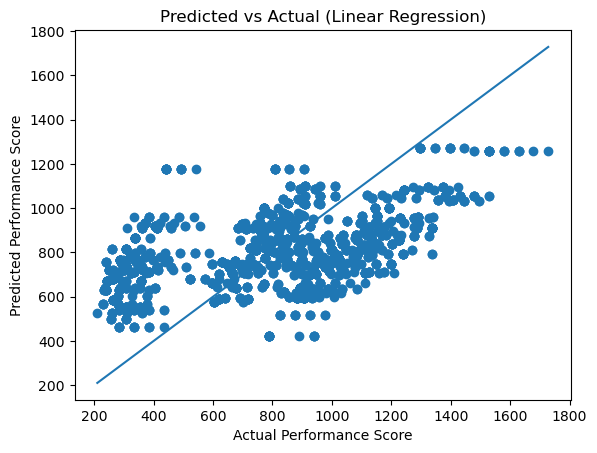

In [41]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Performance Score")
plt.ylabel("Predicted Performance Score")
plt.title("Predicted vs Actual (Linear Regression)")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

The plots aren't hugging the diagonal, but they're pretty uniform in terms of distance from the diagonal. The center is tightly clustered, and there don't seem to be crazy outliers. The amount of over and under predictions seem to be uniform overall despite not following the trend of the diagonal. This aligns with what the coefficient indicated earlier.

### Random Forest Model

In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Random Forest Results:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R^2:", r2)

Random Forest Results:
MSE: 1736.4377780530262
RMSE: 41.67058648558989
R^2: 0.9836007837210755


The results are drastically different from the linear regression model. 

The r^2 is really high (98.4% compared to 25.5%), which suggests that the model is capturing the relationship between the features really well.

The MSE is much smaller than the previous results (1736 vs. 78,865).

The RMSE is consistent with the lower MSE, showing 42 points of difference against the 1490 range.

Overall, this is a major improvement in variance.


### Random Forest Visual

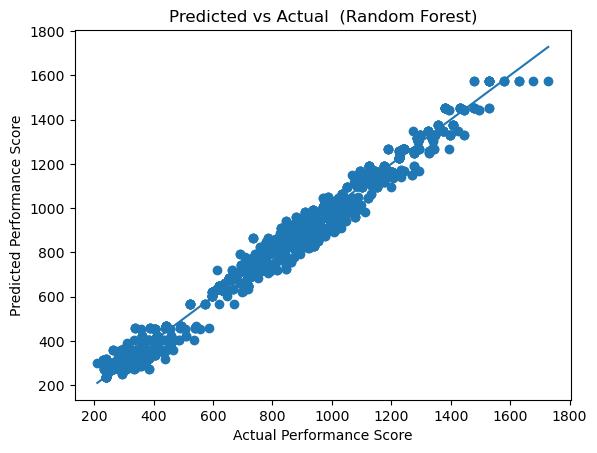

In [49]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Performance Score")
plt.ylabel("Predicted Performance Score")
plt.title("Predicted vs Actual  (Random Forest)")

# Optional: perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

The plots hug the line much more closely with this model. There is overall less vertical spread across the entire graph and it aligns with the line.

## 5. Discussion ##

The most obvious thing is that the two models performed very differently. Linear regression had a low performance with low r^2 with high errors, while random forest had high r^2, with low error. 

The random forest model likely performed better due to the features and the target being non-linear. The skills and race features combined in complex ways that the linear regression model couldn't seem to capture well. 

The RMSE difference between the two models were very wide too. Random forest predictions are much closer to the actual values on average.

With the visualizations, we were able to see that the linear model had a wide scatter and weak alignment with the diagonal. On the other hand, the random forest model showed points that were clustered much closer to the diagonal. This visualization reflects the metric differences.

The limitations were that the heuristic (performance_score) was what we targetted and not real world measured performances. As this was a generated, synthetic dataset, there may be possible overfitting with the random forest model since it performed really well.


## 6. Conclusion ##

In this project, I did my best to build a synthetic dataset to reflect the actual game. Strangely, modeling the data to predict the performance score. After preparing the data for modeling, I used the Linear Regression and Random Forest models to compare how the dataset performed on each. In doing that, I learned how different models perform with the same dataset. After evaluating the r^2, MSE, and RMSE, I was able to see a clearer relationship between the metrics and what the model learned. Again, because this is a synthetic and heuristic-based dataset, there may be potential overfitting. 

If I were to do this again, I would try different models such as XGBoost or Gradient Boosting to see how the same exact dataset would perform. Another thing I would try would be to tune the hyperparameters. I think how I split my data would change the performance, so I would try to explore feature importance or selection.

With all that said, given the dataset that I had, the random forest model was more suitable due to its ability to detect the patterns between non-linear relationships between the features. This reflects my intro, which basically stated that contextual data is important.